<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/06_SARIMA_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 실습: 계절성과 SARIMA
**Notebook:** `06_SARIMA_Modeling.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 계절성이 있는 시계열 데이터를 불러오고 구조를 확인합니다.
2. 결측치를 처리하고 월별 빈도로 정리합니다.
3. 시계열 분해(Decomposition)를 통해 Trend / Seasonal / Residual을 시각적으로 확인합니다.
4. ACF와 PACF를 통해 계절성 스파이크를 관찰합니다.
5. SARIMA의 비계절 차수 `(p, d, q)`와 계절 차수 `(P, D, Q, m)`를 비교하며 탐색합니다.
6. 비계절 ARIMA와 계절형 SARIMA의 예측 성능을 비교합니다.
7. 잔차 진단과 MAPE 계산을 통해 최종 모형을 해석합니다.

---

## 왜 이 실습이 중요한가?
현실의 많은 시계열 데이터는 단순한 추세만이 아니라 **반복되는 계절 패턴**을 포함합니다.  
이러한 계절성을 무시하고 일반 ARIMA만 적용하면 예측이 평탄해지거나 반복 구조를 따라가지 못하는 문제가 생길 수 있습니다.

이번 실습의 핵심은 단순히 SARIMA 함수를 실행하는 것이 아니라,  
**왜 계절 차분이 필요한지**, **계절 주기 `m`이 무엇을 의미하는지**, **계절형 모형이 실제 예측에서 어떤 차이를 만드는지**를 직접 확인하는 데 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 실습용 계절 시계열 데이터 불러오기
이번 실습에서는 `statsmodels`에 포함된 **CO2 시계열 데이터**를 사용합니다.

이 데이터는
- 장기 추세가 존재하고
- 계절성이 뚜렷하며
- 일부 결측이 포함되어 있어

SARIMA 실습용 예제로 매우 적합합니다.


In [3]:
# ============================================
# 3. CO2 데이터 로드
# ============================================

import statsmodels.api as sm

co2 = sm.datasets.co2.load_pandas().data.copy()

print("Raw shape:", co2.shape)
display(co2.head())


Raw shape: (2284, 1)


,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


## 3. 데이터 구조와 결측 확인
시계열 모델링 전에 다음을 먼저 확인합니다.

1. 인덱스가 날짜형인지
2. 결측치가 얼마나 있는지
3. 현재 데이터의 관측 빈도가 무엇인지


In [4]:
# ============================================
# 4. 데이터 구조 점검
# ============================================

print("===== info =====")
print(co2.info())

print("\n===== index type =====")
print(type(co2.index))

print("\n===== missing values =====")
print(co2.isna().sum())

print("\n===== inferred frequency =====")
try:
    print(pd.infer_freq(co2.index))
except Exception as e:
    print("빈도 추정 실패:", e)


===== info =====
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2284 entries, 1958-03-29 to 2001-12-29
Freq: W-SAT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   co2     2225 non-null   float64
dtypes: float64(1)
memory usage: 35.7 KB
None

===== index type =====
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>

===== missing values =====
co2    59
dtype: int64

===== inferred frequency =====
W-SAT


## 4. 결측치 처리와 월별 재표집
CO2 데이터는 주간 관측과 결측을 포함하고 있습니다.  
이번 실습에서는 다음 순서로 정리합니다.

1. 선형 보간으로 결측치 처리
2. 월별 평균으로 재표집
3. 계절 주기 `m = 12`를 갖는 월별 시계열로 변환

이후의 SARIMA 실습은 이 월별 데이터 기준으로 진행합니다.


In [5]:
# ============================================
# 5. 결측 보간 + 월별 재표집
# ============================================

co2_interp = co2.copy()
co2_interp["co2"] = co2_interp["co2"].interpolate(method="linear")

co2_monthly = co2_interp["co2"].resample("M").mean()
co2_monthly.name = "CO2"

print("Monthly length:", len(co2_monthly))
print("Monthly missing values:", co2_monthly.isna().sum())
display(co2_monthly.head())


Monthly length: 526
Monthly missing values: 0


,CO2
1958-03-31,316.100
1958-04-30,317.200
1958-05-31,317.410
1958-06-30,316.675
1958-07-31,315.625


## 5. 원시 시계열 플롯
먼저 월별 시계열을 그려서 계절성과 추세를 눈으로 확인합니다.

관찰 포인트:
- 장기적으로 상승하는가?
- 해마다 비슷한 계절 파동이 반복되는가?
- 계절 진폭이 일정한가?


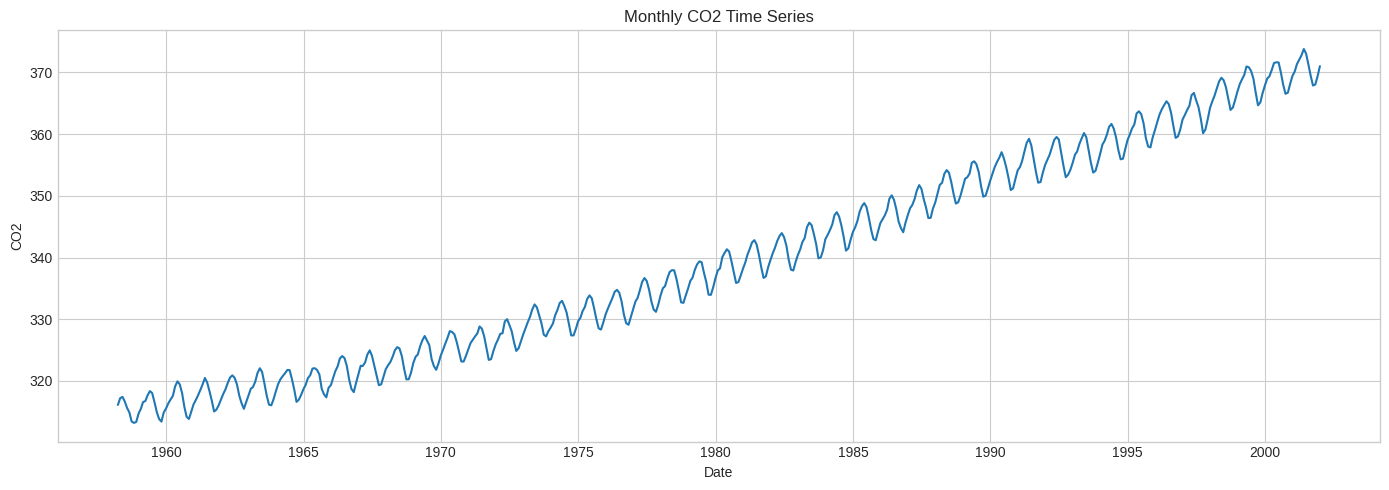

In [6]:
# ============================================
# 6. 월별 CO2 시계열 플롯
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(co2_monthly.index, co2_monthly, linewidth=1.5)

plt.title("Monthly CO2 Time Series")
plt.xlabel("Date")
plt.ylabel("CO2")
plt.tight_layout()
plt.show()


## 6. 시계열 분해(Decomposition)
계절성이 있는지 직관적으로 보기 위해 고전적 분해를 수행합니다.

여기서는 **가법(Additive) 분해**를 사용합니다.
- Observed
- Trend
- Seasonal
- Residual

를 한 번에 확인할 수 있습니다.


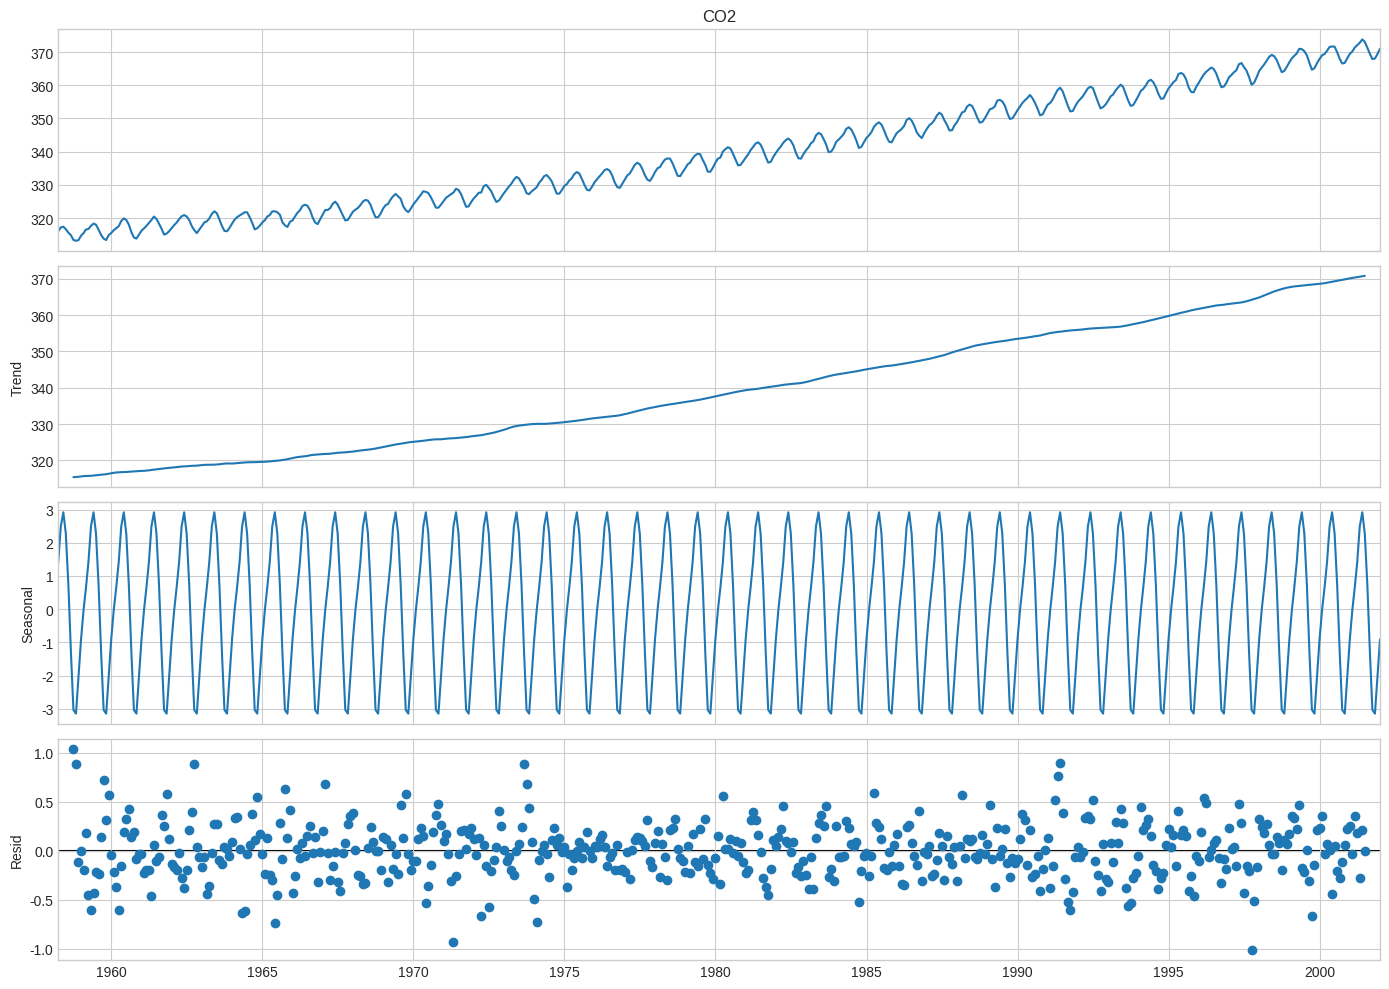

In [7]:
# ============================================
# 7. 계절 분해
# ============================================

from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(co2_monthly, model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## 7. 계절 차분과 일반 차분
SARIMA에서는 두 종류의 차분을 구분해야 합니다.

- 일반 차분: `y_t - y_(t-1)`
- 계절 차분: `y_t - y_(t-m)`

월별 데이터에서 `m = 12`이므로, 계절 차분은 작년 같은 달과의 차이를 의미합니다.


In [8]:
# ============================================
# 8. 일반 차분과 계절 차분 생성
# ============================================

diff1 = co2_monthly.diff()
seasonal_diff = co2_monthly.diff(12)
diff1_seasonal = diff1.diff(12)

display(pd.DataFrame({
    "Original": co2_monthly.head(15),
    "Diff1": diff1.head(15),
    "SeasonalDiff12": seasonal_diff.head(15)
}))


,Original,Diff1,SeasonalDiff12
1958-03-31,316.100000,NaN,NaN
1958-04-30,317.200000,1.100000,NaN
1958-05-31,317.410000,0.210000,NaN
1958-06-30,316.675000,-0.735000,NaN
1958-07-31,315.625000,-1.050000,NaN
1958-08-31,314.870000,-0.755000,NaN
1958-09-30,313.416667,-1.453333,NaN
1958-10-31,313.194444,-0.222222,NaN
1958-11-30,313.351111,0.156667,NaN
1958-12-31,314.700000,1.348889,NaN


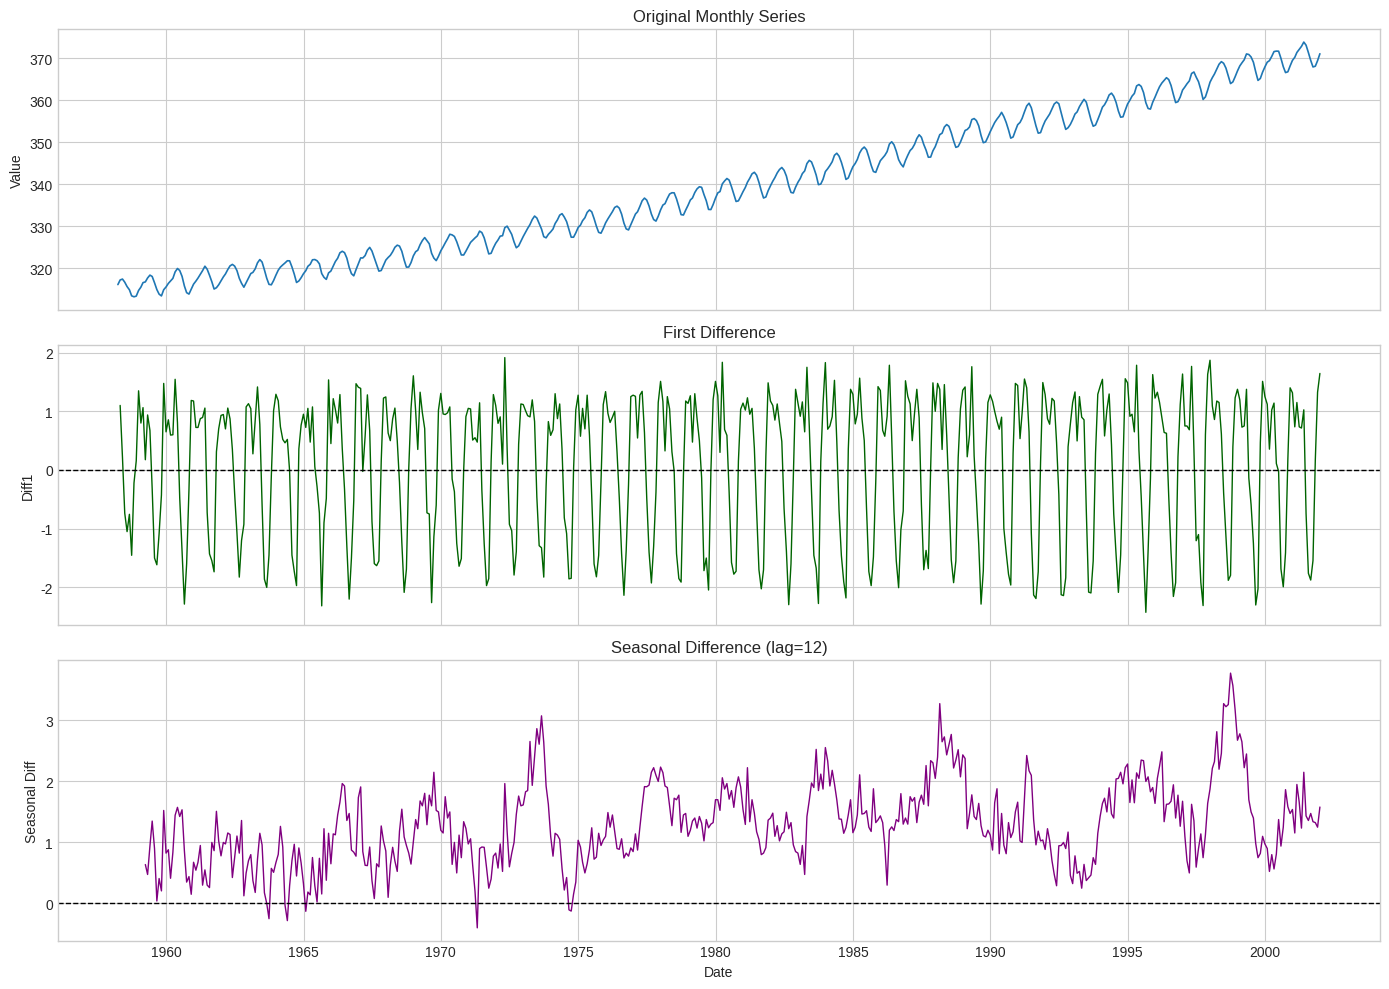

In [9]:
# ============================================
# 9. 차분 비교 플롯
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(co2_monthly.index, co2_monthly, linewidth=1.2)
axes[0].set_title("Original Monthly Series")
axes[0].set_ylabel("Value")

axes[1].plot(diff1.index, diff1, color="darkgreen", linewidth=1.0)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("First Difference")
axes[1].set_ylabel("Diff1")

axes[2].plot(seasonal_diff.index, seasonal_diff, color="purple", linewidth=1.0)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Seasonal Difference (lag=12)")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Seasonal Diff")

plt.tight_layout()
plt.show()


## 8. 정상성 점검 함수
계절 차분이 필요한지 판단하기 위해 ADF 검정을 확인합니다.

- 귀무가설: 단위근이 존재한다 (비정상)
- p-value가 충분히 작으면 정상성에 더 가까움


In [10]:
# ============================================
# 10. ADF 검정 함수
# ============================================

from statsmodels.tsa.stattools import adfuller

def adf_report(series, name="Series"):
    series = pd.Series(series).dropna()
    result = adfuller(series, autolag="AIC")
    print(f"===== {name} =====")
    print("ADF Statistic :", round(result[0], 4))
    print("ADF p-value   :", round(result[1], 4))
    print("-" * 40)


In [11]:
# ============================================
# 11. 원시 / 일반차분 / 계절차분 ADF 비교
# ============================================

adf_report(co2_monthly, "Original Monthly CO2")
adf_report(diff1, "First Difference")
adf_report(seasonal_diff, "Seasonal Difference (lag=12)")
adf_report(diff1_seasonal, "First + Seasonal Difference")


===== Original Monthly CO2 =====
ADF Statistic : 2.3975
ADF p-value   : 0.999
----------------------------------------
===== First Difference =====
ADF Statistic : -4.8987
ADF p-value   : 0.0
----------------------------------------
===== Seasonal Difference (lag=12) =====
ADF Statistic : -4.2768
ADF p-value   : 0.0005
----------------------------------------
===== First + Seasonal Difference =====
ADF Statistic : -8.484
ADF p-value   : 0.0
----------------------------------------


## 9. ACF / PACF로 계절성 스파이크 확인
계절성이 있는 시계열은 ACF에서 `lag = 12, 24, 36 ...` 근처에 계절 스파이크가 나타나는 경우가 많습니다.

여기서는
1. 원시 시계열
2. 1차 + 계절 차분 시계열

두 가지를 비교합니다.


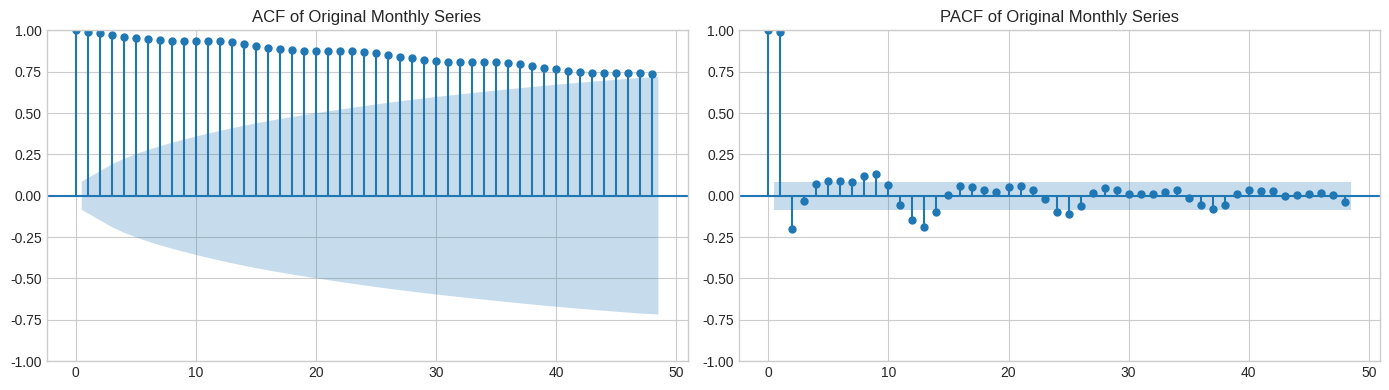

In [12]:
# ============================================
# 12. 원시 시계열의 ACF / PACF
# ============================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(co2_monthly.dropna(), lags=48, ax=axes[0])
plot_pacf(co2_monthly.dropna(), lags=48, ax=axes[1], method="ywm")

axes[0].set_title("ACF of Original Monthly Series")
axes[1].set_title("PACF of Original Monthly Series")

plt.tight_layout()
plt.show()


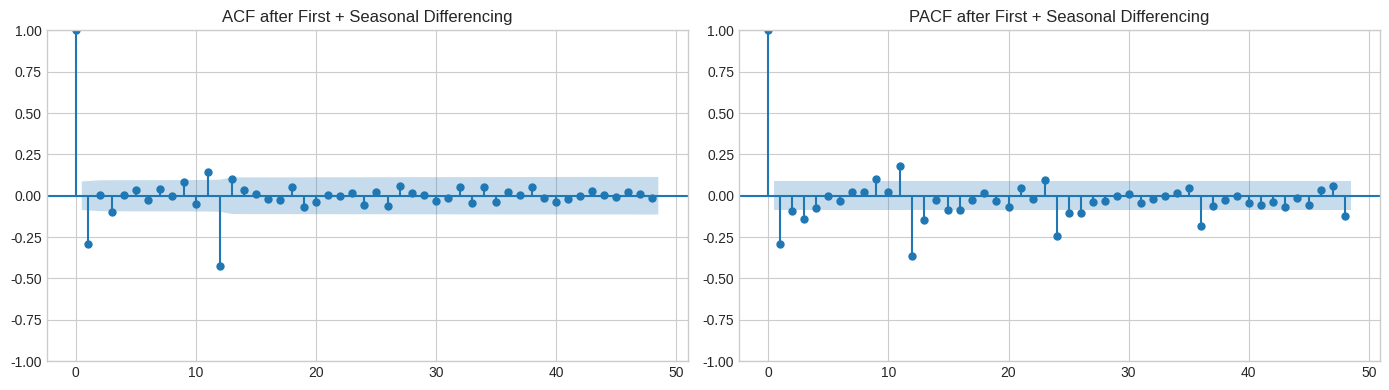

In [13]:
# ============================================
# 13. 차분 후 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff1_seasonal.dropna(), lags=48, ax=axes[0])
plot_pacf(diff1_seasonal.dropna(), lags=48, ax=axes[1], method="ywm")

axes[0].set_title("ACF after First + Seasonal Differencing")
axes[1].set_title("PACF after First + Seasonal Differencing")

plt.tight_layout()
plt.show()


## 10. Train / Test 분할
예측 성능을 보기 위해 마지막 24개월을 테스트 구간으로 두겠습니다.  
시계열에서는 무작위 분할이 아니라 **시간 순서 유지**가 핵심입니다.


In [14]:
# ============================================
# 14. Train / Test split
# ============================================

test_size = 24

train = co2_monthly.iloc[:-test_size]
test = co2_monthly.iloc[-test_size:]

print("Train length:", len(train))
print("Test length :", len(test))
print("Seasonal period m =", 12)


Train length: 502
Test length : 24
Seasonal period m = 12


## 11. 비교 기준선(Baseline): Seasonal Naive
SARIMA 성능을 보기 전에, 단순한 **Seasonal Naive** 기준선을 만듭니다.

월별 데이터에서 Seasonal Naive는  
"이번 달 값은 작년 같은 달 값과 같다"  
라고 예측하는 방식입니다.


In [15]:
# ============================================
# 15. Seasonal Naive baseline
# ============================================

seasonal_naive_forecast = co2_monthly.shift(12).iloc[-test_size:]

baseline_df = pd.DataFrame({
    "Actual": test,
    "Seasonal_Naive": seasonal_naive_forecast
})

display(baseline_df.head())


,Actual,Seasonal_Naive
2000-01-31,369.020,368.120
2000-02-29,369.375,368.850
2000-03-31,370.400,369.600
2000-04-30,371.540,370.975
2000-05-31,371.650,370.840


## 12. SARIMA와 비계절 ARIMA 비교를 위한 그리드 탐색
이번 실습에서는 작은 범위에서 다음 조합을 비교합니다.

- 비계절 ARIMA: `(p, d, q)`
- 계절 SARIMA: `(P, D, Q, 12)`

탐색 범위는 계산량을 줄이기 위해 제한합니다.


In [16]:
# ============================================
# 16. SARIMAX 불러오기
# ============================================

from statsmodels.tsa.statespace.sarimax import SARIMAX


In [17]:
# ============================================
# 17. 비계절 ARIMA 후보 탐색
# ============================================

arima_results = []

for p in [0, 1, 2]:
    for d in [0, 1]:
        for q in [0, 1, 2]:
            try:
                model = SARIMAX(
                    train,
                    order=(p, d, q),
                    seasonal_order=(0, 0, 0, 12),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(disp=False)
                arima_results.append({
                    "Model": "ARIMA",
                    "p": p, "d": d, "q": q,
                    "P": 0, "D": 0, "Q": 0, "m": 12,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic
                })
            except Exception:
                pass

arima_df = pd.DataFrame(arima_results).sort_values("AIC").reset_index(drop=True)
display(arima_df.head(10))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,p,d,q,P,D,Q,m,AIC,BIC
0,ARIMA,2,1,1,0,0,0,12,979.610829,996.461253
1,ARIMA,2,1,2,0,0,0,12,980.135475,1001.188476
2,ARIMA,2,1,0,0,0,0,12,1094.432902,1107.070720
3,ARIMA,1,1,2,0,0,0,12,1115.738141,1132.580542
4,ARIMA,2,0,2,0,0,0,12,1122.124482,1143.187512
5,ARIMA,0,1,2,0,0,0,12,1145.995822,1158.627623
6,ARIMA,1,0,2,0,0,0,12,1149.003557,1165.853982
7,ARIMA,1,1,1,0,0,0,12,1167.147729,1179.785547
8,ARIMA,2,0,1,0,0,0,12,1170.160053,1187.018486
9,ARIMA,1,1,0,0,0,0,12,1239.389616,1247.818832


In [18]:
# ============================================
# 18. SARIMA 후보 탐색
# ============================================

sarima_results = []

for p in [0, 1]:
    for d in [0, 1]:
        for q in [0, 1]:
            for P in [0, 1]:
                for D in [0, 1]:
                    for Q in [0, 1]:
                        try:
                            model = SARIMAX(
                                train,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            fitted = model.fit(disp=False)
                            sarima_results.append({
                                "Model": "SARIMA",
                                "p": p, "d": d, "q": q,
                                "P": P, "D": D, "Q": Q, "m": 12,
                                "AIC": fitted.aic,
                                "BIC": fitted.bic
                            })
                        except Exception:
                            pass

sarima_df = pd.DataFrame(sarima_results).sort_values("AIC").reset_index(drop=True)
display(sarima_df.head(10))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

,Model,p,d,q,P,D,Q,m,AIC,BIC
0,SARIMA,1,1,1,1,1,1,12,196.839880,217.656454
1,SARIMA,0,1,1,1,1,1,12,199.498664,216.151923
2,SARIMA,1,0,1,1,1,1,12,199.769080,220.596169
3,SARIMA,1,1,1,0,1,1,12,203.547871,220.201130
4,SARIMA,0,1,1,0,1,1,12,204.823606,217.313551
5,SARIMA,1,1,0,1,1,1,12,207.568757,224.230429
6,SARIMA,1,0,1,0,1,1,12,207.906059,224.567731
7,SARIMA,1,1,1,1,0,1,12,210.909000,231.850321
8,SARIMA,1,1,0,0,1,1,12,213.346856,225.843109
9,SARIMA,0,1,1,1,0,1,12,213.367452,230.120508


## 13. 최적 ARIMA와 최적 SARIMA 비교
이제 각각 AIC가 가장 낮은 비계절 ARIMA와 계절 SARIMA를 선택해 비교합니다.


In [19]:
# ============================================
# 19. 최적 모형 선택
# ============================================

best_arima = arima_df.iloc[0].to_dict()
best_sarima = sarima_df.iloc[0].to_dict()

print("Best ARIMA:")
print(best_arima)
print("\nBest SARIMA:")
print(best_sarima)


Best ARIMA:
{'Model': 'ARIMA', 'p': 2, 'd': 1, 'q': 1, 'P': 0, 'D': 0, 'Q': 0, 'm': 12, 'AIC': 979.6108290365577, 'BIC': 996.4612534195637}

Best SARIMA:
{'Model': 'SARIMA', 'p': 1, 'd': 1, 'q': 1, 'P': 1, 'D': 1, 'Q': 1, 'm': 12, 'AIC': 196.8398796633325, 'BIC': 217.65645368350573}


In [20]:
# ============================================
# 20. 최적 ARIMA 적합
# ============================================

best_arima_model = SARIMAX(
    train,
    order=(int(best_arima["p"]), int(best_arima["d"]), int(best_arima["q"])),
    seasonal_order=(0, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(best_arima_model.summary())


                               SARIMAX Results                                
Dep. Variable:                    CO2   No. Observations:                  502
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -485.805
Date:                Sun, 15 Mar 2026   AIC                            979.611
Time:                        01:42:57   BIC                            996.461
Sample:                    03-31-1958   HQIC                           986.223
                         - 12-31-1999                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5460      0.029     54.022      0.000       1.490       1.602
ar.L2         -0.8411      0.033    -25.744      0.000      -0.905      -0.777
ma.L1         -0.8035      0.040    -20.232      0.0

In [21]:
# ============================================
# 21. 최적 SARIMA 적합
# ============================================

best_sarima_model = SARIMAX(
    train,
    order=(int(best_sarima["p"]), int(best_sarima["d"]), int(best_sarima["q"])),
    seasonal_order=(int(best_sarima["P"]), int(best_sarima["D"]), int(best_sarima["Q"]), 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(best_sarima_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                CO2   No. Observations:                  502
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -93.420
Date:                            Sun, 15 Mar 2026   AIC                            196.840
Time:                                    01:43:04   BIC                            217.656
Sample:                                03-31-1958   HQIC                           205.026
                                     - 12-31-1999                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2257      0.124      1.815      0.070      -0.018       0.470
ma.L1         -0.5393      0.111   

## 14. 잔차 진단
SARIMA가 적절하다면 잔차에는 더 이상 뚜렷한 계절 자기상관이 남지 않는 것이 이상적입니다.

여기서는
1. 잔차 시각화
2. 잔차 ACF
3. Ljung–Box 검정

을 수행합니다.


In [22]:
# ============================================
# 22. 최적 SARIMA 잔차 추출
# ============================================

sarima_resid = best_sarima_model.resid
display(sarima_resid.head())


,0
1958-03-31,316.100000
1958-04-30,-22.684519
1958-05-31,-2.555844
1958-06-30,-1.067182
1958-07-31,-1.003002


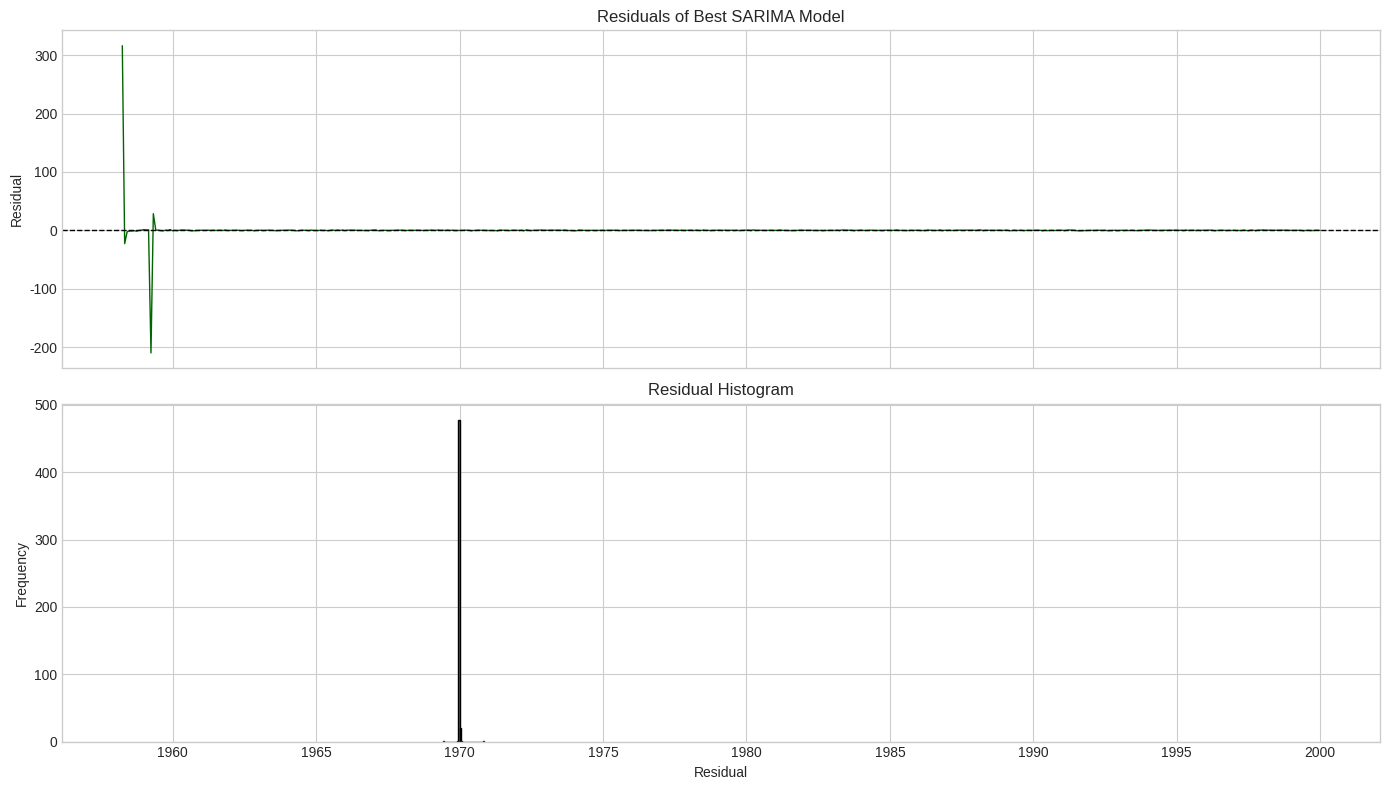

In [23]:
# ============================================
# 23. 잔차 시각화
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(sarima_resid, color="darkgreen", linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals of Best SARIMA Model")
axes[0].set_ylabel("Residual")

axes[1].hist(sarima_resid.dropna(), bins=30, edgecolor="black")
axes[1].set_title("Residual Histogram")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


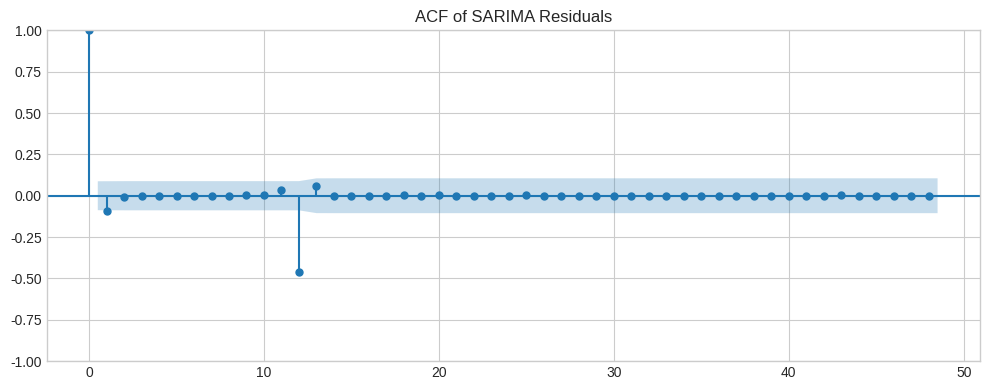

In [24]:
# ============================================
# 24. 잔차의 ACF
# ============================================

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(sarima_resid.dropna(), lags=48, ax=ax)
ax.set_title("ACF of SARIMA Residuals")

plt.tight_layout()
plt.show()


In [25]:
# ============================================
# 25. Ljung-Box 검정
# ============================================

from statsmodels.stats.diagnostic import acorr_ljungbox

lb_df = acorr_ljungbox(sarima_resid.dropna(), lags=[12, 24], return_df=True)
display(lb_df)


,lb_stat,lb_pvalue
12,114.601300,7.330791e-19
24,116.552809,3.971568e-14


## 15. 테스트 구간 예측
이제 비계절 ARIMA와 SARIMA를 각각 테스트 구간에 대해 예측하고 비교합니다.


In [26]:
# ============================================
# 26. ARIMA 예측
# ============================================

arima_forecast_result = best_arima_model.get_forecast(steps=len(test))
arima_forecast = arima_forecast_result.predicted_mean

# SARIMA 예측
sarima_forecast_result = best_sarima_model.get_forecast(steps=len(test))
sarima_forecast = sarima_forecast_result.predicted_mean

forecast_df = pd.DataFrame({
    "Actual": test,
    "Seasonal_Naive": seasonal_naive_forecast,
    "ARIMA": arima_forecast,
    "SARIMA": sarima_forecast
})

display(forecast_df.head())


,Actual,Seasonal_Naive,ARIMA,SARIMA
2000-01-31,369.020,368.120,368.974402,369.008842
2000-02-29,369.375,368.850,369.584011,369.818465
2000-03-31,370.400,369.600,369.622763,370.754899
2000-04-30,371.540,370.975,369.169927,372.038649
2000-05-31,371.650,370.840,368.437267,372.484807


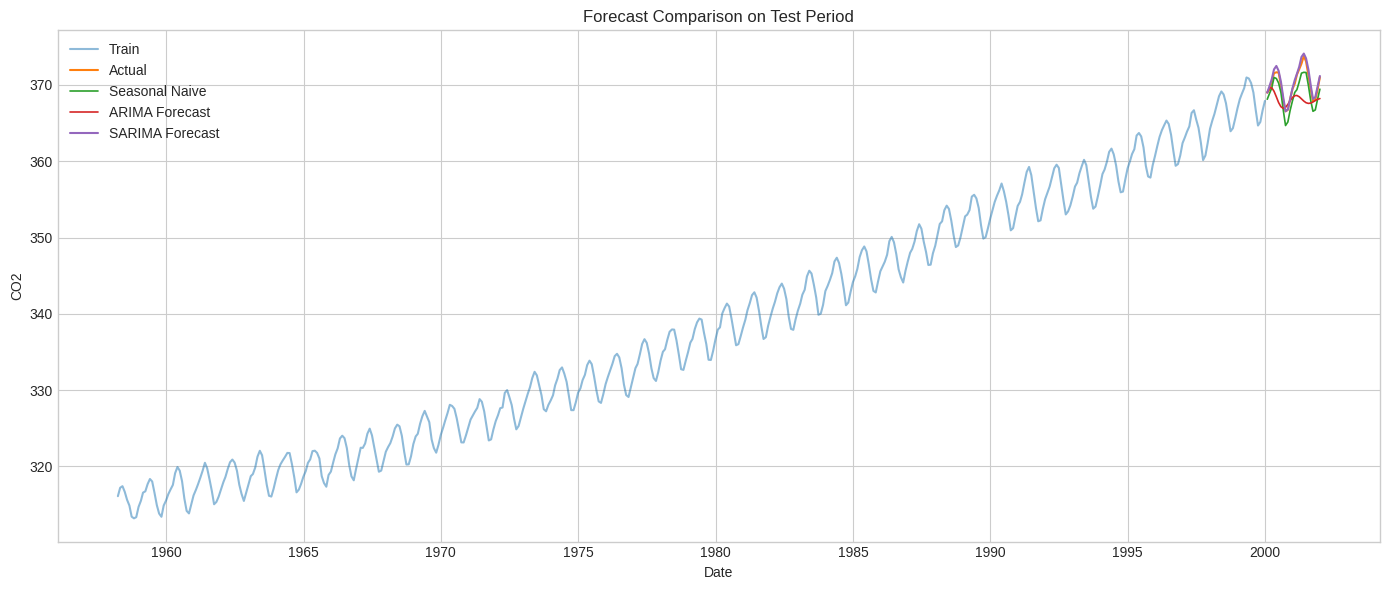

In [27]:
# ============================================
# 27. 예측값 비교 플롯
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train", alpha=0.5)
plt.plot(test.index, test, label="Actual", linewidth=1.5)
plt.plot(seasonal_naive_forecast.index, seasonal_naive_forecast, label="Seasonal Naive", linewidth=1.2)
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", linewidth=1.2)
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA Forecast", linewidth=1.5)

plt.title("Forecast Comparison on Test Period")
plt.xlabel("Date")
plt.ylabel("CO2")
plt.legend()
plt.tight_layout()
plt.show()


## 16. MAPE 계산
이번 실습에서는 세 가지 예측을 비교합니다.

- Seasonal Naive
- ARIMA
- SARIMA

MAPE는 다음과 같이 해석할 수 있습니다.

- 값이 작을수록 예측 오차율이 낮음
- 다만 값이 0에 매우 가까운 시계열에서는 주의가 필요함


In [28]:
# ============================================
# 28. MAPE 함수
# ============================================

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [29]:
# ============================================
# 29. MAPE 비교
# ============================================

mape_naive = mape(test, seasonal_naive_forecast)
mape_arima = mape(test, arima_forecast)
mape_sarima = mape(test, sarima_forecast)

mape_df = pd.DataFrame({
    "Model": ["Seasonal Naive", "ARIMA", "SARIMA"],
    "MAPE": [mape_naive, mape_arima, mape_sarima]
}).sort_values("MAPE")

display(mape_df)


,Model,MAPE
2,SARIMA,0.093963
0,Seasonal Naive,0.355121
1,ARIMA,0.567177


## 17. 예측 성능 해석
이제 다음 질문에 답할 수 있어야 합니다.

- Seasonal Naive보다 SARIMA가 더 나은가?
- 비계절 ARIMA보다 SARIMA가 더 나은가?
- 계절 차수 `(P, D, Q, m)`가 실제 예측 개선에 기여했는가?

특히 계절성이 강한 데이터라면, SARIMA가 ARIMA보다 더 자연스럽게 반복 구조를 따라가는 경우가 많습니다.


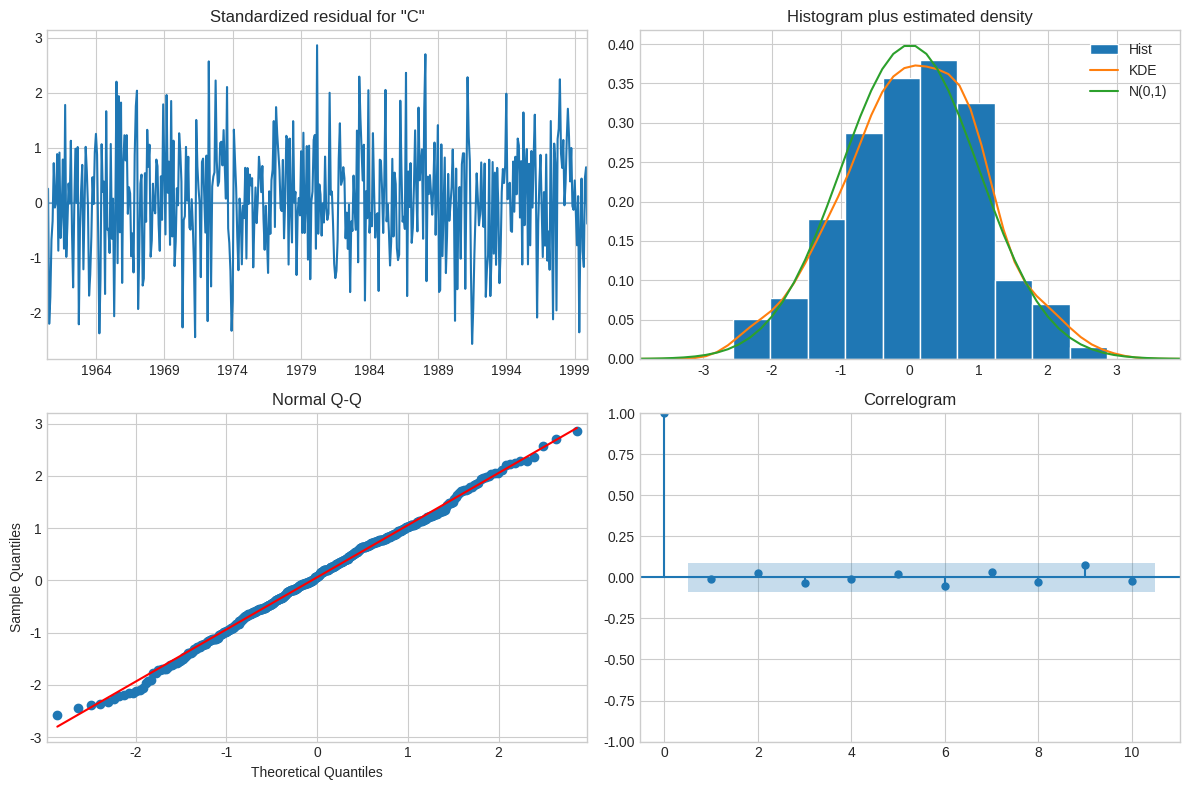

In [30]:
# ============================================
# 30. 최종 모델 진단 그래프
# ============================================

best_sarima_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()


## 18. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 계절성은 일정한 주기로 반복되는 구조적 패턴이다.
- SARIMA는 일반 ARIMA에 계절 파라미터 `(P, D, Q, m)`를 추가한 확장 모형이다.
- 계절 차분은 `y_t - y_(t-m)` 형태로 해석할 수 있다.
- ACF에서 계절 주기의 배수에 스파이크가 나타나면 계절성을 의심할 수 있다.
- 비계절 ARIMA와 SARIMA는 정보 기준과 테스트 예측 성능을 함께 비교해야 한다.
- 최종 모형은 잔차가 백색잡음에 가까운지 반드시 점검해야 한다.


## 19. 연습문제 (Exercises)

1. CO2 데이터 대신 다른 월별 계절 시계열을 사용하여 같은 SARIMA 탐색을 수행하시오.

2. 계절 주기 `m = 12` 대신 잘못된 값을 넣으면 예측이 어떻게 달라지는지 실험해 보시오.

3. `D = 0`과 `D = 1`의 차이를 그래프와 ADF 결과를 바탕으로 설명하시오.

4. Seasonal Naive와 SARIMA의 MAPE 차이가 매우 작다면, 어떤 모형을 선택할지 논의하시오.

5. 분기별 데이터라면 계절 주기 `m`을 얼마로 두어야 하는지, 그리고 왜 그런지 설명하시오.
